In [1]:
import os
import sys
import importlib

src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import Plots_notebook as pltn
importlib.reload(pltn)
import Extraccion_FBREF_Barcelona as exfbref
importlib.reload(exfbref)
import Limpia_FBREF_Barcelona as lfbref


In [2]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO
import re
import matplotlib.pyplot as plt
from mplsoccer import Radar, FontManager, grid
import numpy as np
import plotly.express as  px
from matplotlib.font_manager import FontProperties


In [8]:
season = "2024-2025"
players_stats_2425 = exfbref.scrape_and_save_players(season, headless=False)
players_stats_2425


Extraída tabla con ID: stats_standard_12
Extraída tabla con ID: matchlogs_for
Extraída tabla con ID: stats_keeper_12
Extraída tabla con ID: stats_keeper_adv_12
Extraída tabla con ID: stats_shooting_12
Extraída tabla con ID: stats_passing_12
Extraída tabla con ID: stats_passing_types_12
Extraída tabla con ID: stats_gca_12
Extraída tabla con ID: stats_defense_12
Extraída tabla con ID: stats_possession_12
Extraída tabla con ID: stats_playing_time_12
Extraída tabla con ID: stats_misc_12
Extraída tabla con ID: results2024-2025121_overall
Extraída tabla con ID: results2024-2025121_home_away


{'stats_standard_12':        Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0  \
                    Player             Nation                Pos   
 0                   Pedri             es ESP                 MF   
 1                Raphinha             br BRA              FW,MF   
 2      Robert Lewandowski             pl POL                 FW   
 3            Lamine Yamal             es ESP                 FW   
 4             Pau Cubarsí             es ESP                 DF   
 5            Jules Koundé             fr FRA                 DF   
 6          Iñigo Martínez             es ESP                 DF   
 7         Alejandro Balde             es ESP                 DF   
 8             Marc Casado             es ESP                 MF   
 9              Iñaki Peña             es ESP                 GK   
 10      Wojciech Szczęsny             pl POL                 GK   
 11            Eric García             es ESP              DF,MF   
 12                   Gavi 

In [9]:
season = "2025-2026"
players_stats_2526 = exfbref.scrape_and_save_players(season, headless=False)
players_stats_2526

Extraída tabla con ID: stats_standard_12
Extraída tabla con ID: matchlogs_for
Extraída tabla con ID: stats_keeper_12
Extraída tabla con ID: stats_keeper_adv_12
Extraída tabla con ID: stats_shooting_12
Extraída tabla con ID: stats_passing_12
Extraída tabla con ID: stats_passing_types_12
Extraída tabla con ID: stats_gca_12
Extraída tabla con ID: stats_defense_12
Extraída tabla con ID: stats_possession_12
Extraída tabla con ID: stats_playing_time_12
Extraída tabla con ID: stats_misc_12
Extraída tabla con ID: results2025-2026121_overall
Extraída tabla con ID: results2025-2026121_home_away


{'stats_standard_12':      Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0  \
                  Player             Nation                Pos   
 0           Eric García             es ESP              DF,MF   
 1           Pau Cubarsí             es ESP                 DF   
 2                 Pedri             es ESP                 MF   
 3          Jules Koundé             fr FRA                 DF   
 4          Lamine Yamal             es ESP                 FW   
 5         Ferrán Torres             es ESP                 FW   
 6       Alejandro Balde             es ESP                 DF   
 7       Marcus Rashford            eng ENG                 FW   
 8           Joan García             es ESP                 GK   
 9       Frenkie de Jong             nl NED                 MF   
 10        Gerard Martín             es ESP                 DF   
 11            Dani Olmo             es ESP                 MF   
 12        Ronald Araújo             uy URU            

In [5]:
def limpia_stat_squads(ruta,team,season):
    df = pd.read_csv(ruta, header=1)
    columnas = []
    for col in df.columns:
        if re.search(r".1$", col):
            col = col.replace('.1','/90')
            columnas.append(col)
        else:
            columnas.append(col)
    df.columns = columnas
    team_stats = df.copy()
    team_stats = team_stats[df.Squad ==  team]
    team_stats['season'] = season
    team_stats['PrgP/90'] = round(team_stats['PrgP']/team_stats['90s'],2)
    team_stats = team_stats.loc[:,['season','PrgP/90','90s', 'xG/90', 'Gls/90', 'xAG/90']]

    return team_stats

In [6]:
barca_stats_2024 = limpia_stat_squads('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2024-2025/Archivos_utilizados/stats_squads_standard_for_2024-2025.csv', 'Barcelona', '2024-2025')


In [7]:
barca_stats_2024

,season,PrgP/90,90s,xG/90,Gls/90,xAG/90
3,2024-2025,58.21,38.0,2.41,2.61,1.78


In [8]:
barca_stats_against_2024 = limpia_stat_squads('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2024-2025/Archivos_utilizados/stats_squads_standard_against_2024-2025.csv','vs Barcelona', '2024-2025')
barca_stats_against_2024.rename(columns={'xG/90':'xGA/90', 'Gls/90':'GA/90'}, inplace=True)
barca_stats_against_2024
barca_stats_against_2024_xGA = barca_stats_against_2024[['season','xGA/90', 'GA/90']]
barca_stats_against_2024_xGA 

,season,xGA/90,GA/90
3,2024-2025,1.1,1.03


In [9]:
barca_stats_2025 = limpia_stat_squads('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2025-2026/Archivos_utilizados/stats_squads_standard_for_2025-2026.csv', 'Barcelona', '2025-2026')


In [10]:
barca_stats_against_2025 = limpia_stat_squads('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2025-2026/Archivos_utilizados/stats_squads_standard_against_2025-2026.csv','vs Barcelona', '2025-2026')
barca_stats_against_2025.rename(columns={'xG/90':'xGA/90', 'Gls/90':'GA/90'}, inplace=True)
barca_stats_against_2025_xGA = barca_stats_against_2025[['season','xGA/90', 'GA/90']]
barca_stats_against_2025_xGA

,season,xGA/90,GA/90
3,2025-2026,1.33,1.25


In [11]:
barca_stats_against = pd.concat([barca_stats_against_2024_xGA, barca_stats_against_2025_xGA], axis=0, ignore_index=True)
barca_stats_against

,season,xGA/90,GA/90
0,2024-2025,1.10,1.03
1,2025-2026,1.33,1.25


In [12]:
barca_stats = pd.concat([barca_stats_2024,barca_stats_2025], axis=0, ignore_index=True)
barca_stats

,season,PrgP/90,90s,xG/90,Gls/90,xAG/90
0,2024-2025,58.21,38.0,2.41,2.61,1.78
1,2025-2026,50.75,16.0,2.28,2.87,1.65


In [13]:
barca_stats = barca_stats.merge(barca_stats_against, on='season', how='left')
barca_stats

,season,PrgP/90,90s,xG/90,Gls/90,xAG/90,xGA/90,GA/90
0,2024-2025,58.21,38.0,2.41,2.61,1.78,1.10,1.03
1,2025-2026,50.75,16.0,2.28,2.87,1.65,1.33,1.25


In [14]:
sca_gca_stats = pd.read_csv('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2025-2026/Archivos_utilizados/stats_squads_gca_for_2025-2026.csv', header=1)
sca_gca_barca_stats = sca_gca_stats.copy()
sca_gca_barca_stats = sca_gca_barca_stats[sca_gca_barca_stats['Squad'] == 'Barcelona']
sca_gca_barca_stats['season'] = '2025-2026'
sca_gca_barca_stats = sca_gca_barca_stats.loc[:,['season', 'SCA90', 'GCA90']]
sca_gca_barca_stats 

,season,SCA90,GCA90
3,2025-2026,36.25,5.25


In [15]:
def limpia_stat_gca(ruta,team,season):
    df = pd.read_csv(ruta, header=1)
    team_stats = df.copy()
    team_stats = team_stats[df.Squad ==  team]
    team_stats['season'] = season
    team_stats = team_stats.loc[:,['season', 'SCA90', 'GCA90']]

    return team_stats

In [16]:
sca_gca_barca_stats_2024_2025 = limpia_stat_gca('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2024-2025/Archivos_utilizados/stats_squads_gca_for_2024-2025.csv', 'Barcelona', '2024-2025')
sca_gca_barca_stats_2025_2026 = limpia_stat_gca('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2025-2026/Archivos_utilizados/stats_squads_gca_for_2025-2026.csv', 'Barcelona', '2025-2026')

In [17]:
sca_gca_barca_stats_2024_2025

,season,SCA90,GCA90
3,2024-2025,31.71,4.53


In [18]:
sca_gca_barca_stats = pd.concat([sca_gca_barca_stats_2024_2025, sca_gca_barca_stats_2025_2026], axis=0, ignore_index=True)

In [19]:
sca_gca_barca_stats.rename(columns={'SCA90':'SCA/90', 'GCA90':'GCA/90'},inplace=True)

In [20]:
barca_stats = pd.merge(barca_stats, sca_gca_barca_stats, on="season", how="inner")

In [21]:
barca_stats['xG_diff/90']=barca_stats['xG/90']-barca_stats['xGA/90']
barca_stats['Gls_diff/90']=barca_stats['Gls/90']-barca_stats['GA/90']

barca_stats

,season,PrgP/90,90s,xG/90,Gls/90,xAG/90,xGA/90,GA/90,SCA/90,GCA/90,xG_diff/90,Gls_diff/90
0,2024-2025,58.21,38.0,2.41,2.61,1.78,1.10,1.03,31.71,4.53,1.31,1.58
1,2025-2026,50.75,16.0,2.28,2.87,1.65,1.33,1.25,36.25,5.25,0.95,1.62


In [22]:
URL1 = ('https://raw.githubusercontent.com/googlefonts/SourceSerifProGFVersion/main/fonts/'
        'SourceSerifPro-Regular.ttf')
serif_regular = FontManager(URL1)
URL2 = ('https://raw.githubusercontent.com/googlefonts/SourceSerifProGFVersion/main/fonts/'
        'SourceSerifPro-ExtraLight.ttf')
serif_extra_light = FontManager(URL2)
URL3 = ('https://raw.githubusercontent.com/google/fonts/main/ofl/rubikmonoone/'
        'RubikMonoOne-Regular.ttf')
rubik_regular = FontManager(URL3)
URL4 = 'https://raw.githubusercontent.com/googlefonts/roboto/main/src/hinted/Roboto-Thin.ttf'
robotto_thin = FontManager(URL4)
URL5 = ('https://raw.githubusercontent.com/google/fonts/main/apache/robotoslab/'
        'RobotoSlab%5Bwght%5D.ttf')
robotto_bold = FontManager(URL5)

roboto_slab_regular = FontProperties(
    fname=robotto_bold.prop.get_file(),
    weight=200
)


# 📊 Análisis Comparativo FC Barcelona — Temporadas 2024/25 vs 2025/26
---

Este notebook analiza el rendimiento del FC Barcelona utilizando métricas agregadas **por 90 minutos**, generadas a partir de datos extraídos desde FBref y limpiados previamente.

Incluye:

- Producción ofensiva (xG, goles reales)
- Concesión defensiva (xGA, goles recibidos)
- Creación de juego (SCA, GCA)
- Progresión (PrgP)
- Diferenciales clave por partido

Text(0.5, 1.0, '(xG por 90 minutos)')

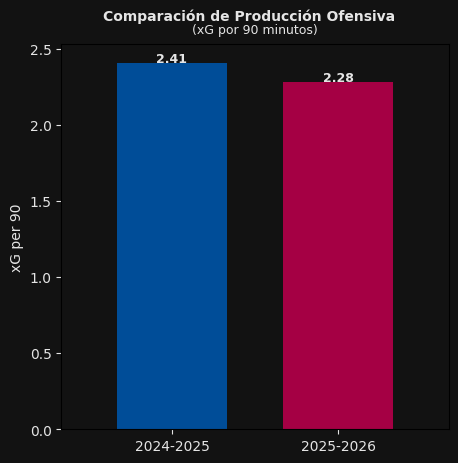

In [ ]:
BARCA_BLAU = "#004D98"
BARCA_GRANA = "#A50044"
BARCA_GRAY = "#E5E5E5"

x = np.array([0, 0.3])#controla el centro de las barras
colores = [BARCA_BLAU, BARCA_GRANA]
plt.figure(figsize=(5,5))

# Fondo negro de la figura
plt.gcf().patch.set_facecolor("#121212")
ax = plt.gca()
ax.set_facecolor("#121212")

plt.bar(x, barca_stats['xG/90'], color=colores, width=0.2)
ax.set_xlim(-0.2, 0.5)#controla el ancho del grafico

# Etiquetas sobre la barra
for i, v in enumerate(barca_stats['xG/90']):
    plt.text(x[i], v + v*0.002, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold", color = BARCA_GRAY)
plt.ylabel('xG per 90', color= BARCA_GRAY)
plt.xticks(x, barca_stats['season'], color=BARCA_GRAY)
plt.tick_params(axis='both', colors = BARCA_GRAY)
plt.suptitle('Comparación de Producción Ofensiva', fontsize=10, fontweight="bold", color = BARCA_GRAY, y=0.95)#y=0.95 junta los tetos del titulo y subtitlo
plt.title('(xG por 90 minutos)', fontsize=9, color = BARCA_GRAY, pad=8)#separa el subtitlo del grafico


xG_per90 — Producción ofensiva real del FC Barcelona

El indicador xG_per90 mide cuántos goles “debería” generar el equipo por cada 90 minutos en función de la calidad de sus ocasiones, independientemente de si finalmente marca o no. Es una métrica clave porque captura la capacidad ofensiva estructural del equipo: cuánto peligro genera de manera sostenida.

En la temporada 2024/25, el Barça registraba 2.41 xG/90, un valor propio de un ataque élite, capaz de crear ocasiones claras de forma recurrente. Sin embargo, en 2025/26, la producción cae a 2.28 xG/90, una reducción del 5,4% en generación ofensiva.

El descenso en xG/90 indica que el Barça llega menos y llega peor, afectando su capacidad para resolver partidos desde el control y forzándolo a depender más de acciones individuales o eficiencia puntual.

In [68]:
metrics = ["xG/90", "Gls/90", "SCA/90", "GCA/90", "PrgP/90", "xGA/90"]
labels  = ["xG", "Goles", "SCA", "GCA", "PrgP", "xGA"]

val_0 = barca_stats.loc[0,metrics].values
val_1 = barca_stats.loc[1,metrics].values

# 3) Rangos por métrica
max_vals = np.maximum(val_0, val_1) * 1.1
low = [0] * len(metrics)#[0] crea una lista con un elemento 0
high = max_vals.tolist()

In [69]:
radar = Radar(labels, low, high,
              num_rings=4,  # the number of concentric circles (excluding center circle)
              # if the ring_width is more than the center_circle_radius then
              # the center circle radius will be wider than the width of the concentric circles
              ring_width=1, center_circle_radius=1)

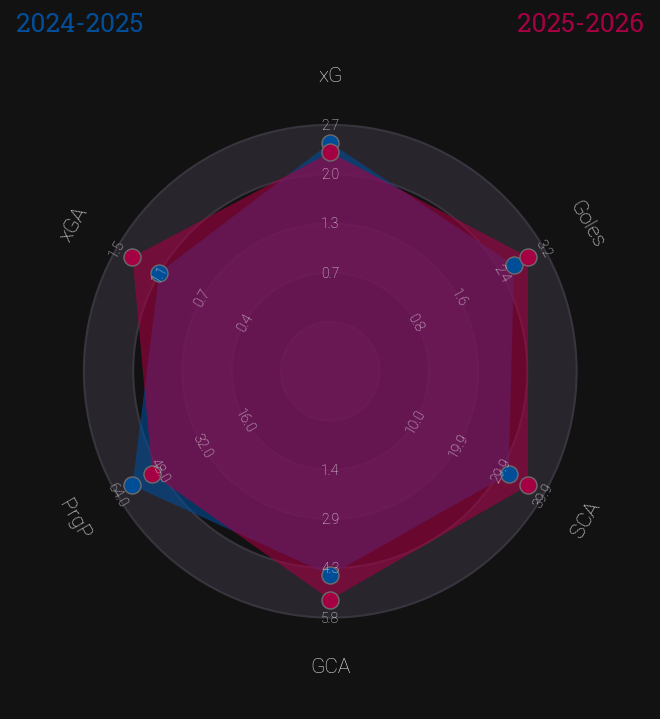

In [71]:
# creating the figure using the grid function from mplsoccer:
fig, axs = grid(figheight=7, grid_height=0.915, title_height=0.06, endnote_height=0.025,
                title_space=0, endnote_space=0, grid_key='radar', axis=False)

# plot the radar
radar.setup_axis(ax=axs['radar'], facecolor='None')
rings_inner = radar.draw_circles(ax=axs['radar'], facecolor='#28252c', edgecolor='#39353f', lw=1.5)
radar_output = radar.draw_radar_compare(val_0, val_1, ax=axs['radar'],
                                        kwargs_radar={'facecolor': BARCA_BLAU, 'alpha': 0.6},
                                        kwargs_compare={'facecolor': BARCA_GRANA, 'alpha': 0.6})
radar_poly, radar_poly2, vertices1, vertices2 = radar_output
range_labels = radar.draw_range_labels(ax=axs['radar'], fontsize=10, color = BARCA_GRAY,
                                       fontproperties=robotto_thin.prop)
param_labels = radar.draw_param_labels(ax=axs['radar'], fontsize=15, color = BARCA_GRAY,
                                       fontproperties=robotto_thin.prop)
axs['radar'].scatter(vertices1[:, 0], vertices1[:, 1],
                     c= BARCA_BLAU, edgecolors='#6d6c6d', marker='o', s=150, zorder=2)
axs['radar'].scatter(vertices2[:, 0], vertices2[:, 1],
                     c= BARCA_GRANA, edgecolors='#6d6c6d', marker='o', s=150, zorder=2)
# adding the endnote and title text (these axes range from 0-1, i.e. 0, 0 is the bottom left)
# Note we are slightly offsetting the text from the edges by 0.01 (1%, e.g. 0.99)
title1_text = axs['title'].text(0.01, 0.65, '2024-2025', fontsize=19, color= BARCA_BLAU,
                                fontproperties=robotto_bold.prop, ha='left', va='center')
title3_text = axs['title'].text(0.99, 0.65, '2025-2026', fontsize=19,
                                fontproperties=robotto_bold.prop,
                                ha='right', va='center', color= BARCA_GRANA)

fig.set_facecolor('#121212')

El radar permite contrastar de forma estructurada el rendimiento del FC Barcelona entre las temporadas 2024/25 y 2025/26 a partir de indicadores que capturan producción ofensiva, creatividad, progresión y solidez defensiva. La normalización de cada eje facilita la identificación de fortalezas y debilidades relativas entre ambas campañas.

Las métricas seleccionadas abarcan diferentes fases del juego:

xG/90 (calidad de las ocasiones generadas)

Gls/90 (eficacia de finalización)

SCA/90 y GCA/90 (creatividad y acciones que derivan en remates o goles)

PrgP/90 (progresión del balón mediante pases)

xGA/90 (calidad de las ocasiones concedidas)

El análisis comparativo revela diferencias nítidas entre los dos ciclos competitivos:

Producción y estructura ofensiva
La temporada 2024/25 genera un volumen mayor de ocasiones de calidad (xG/90), lo que sugiere una estructura ofensiva más consistente y menos dependiente de acciones aisladas. La progresión del balón también es sensiblemente superior (PrgP/90), indicando un control más estable del territorio y una circulación más eficaz.

Creatividad e impacto final
La campaña 2025/26 supera a 2024/25 en SCA/90 y GCA/90, lo que refleja un incremento en la frecuencia de acciones que desembocan en remates y goles. Además, exhibe una mayor eficacia goleadora (Gls/90) pese a generar menos xG, lo que sugiere una mejor conversión pero también un posible rendimiento por encima de las expectativas.

Solidez defensiva
La temporada 2024/25 concede menos peligro (xGA/90), lo que apunta a una estructura defensiva más controlada y con menor exposición.

En términos globales, los datos sugieren que 2024/25 presenta un rendimiento más equilibrado y menos vulnerable, combinando una ofensiva de mayor volumen, una progresión superior y una mejor contención del riesgo defensivo.
Por su parte, 2025/26 emerge como una temporada más volcada en acciones de alto impacto creativo, pero con menor solidez y un perfil más dependiente de la eficacia en áreas específicas.

Desde esta perspectiva, y considerando el peso de los indicadores estructurales (xG, PrgP, xGA), la temporada 2024/25 puede interpretarse como la más sólida y completa entre ambas.

In [28]:
barca_stats

,season,PrgP/90,90s,xG/90,Gls/90,xAG/90,xGA/90,GA/90,SCA/90,GCA/90,xG_diff/90,Gls_diff/90
0,2024-2025,58.21,38.0,2.41,2.61,1.78,1.10,1.03,31.71,4.53,1.31,1.58
1,2025-2026,50.75,16.0,2.28,2.87,1.65,1.33,1.25,36.25,5.25,0.95,1.62


In [29]:
df_long = barca_stats.melt(id_vars='season', value_vars=['Gls/90','GA/90'], var_name='metric', value_name='value')
df_long

,season,metric,value
0,2024-2025,Gls/90,2.61
1,2025-2026,Gls/90,2.87
2,2024-2025,GA/90,1.03
3,2025-2026,GA/90,1.25


In [30]:
df_long['metric'] = df_long['metric'].replace({
    'Gls/90': 'Goles anotados',
    'GA/90': 'Goles recibidos'
})
df_long

,season,metric,value
0,2024-2025,Goles anotados,2.61
1,2025-2026,Goles anotados,2.87
2,2024-2025,Goles recibidos,1.03
3,2025-2026,Goles recibidos,1.25


In [31]:
fig = px.bar(df_long, x='season', y='value', color='metric',
             barmode='group',
             color_discrete_map={'Goles anotados': BARCA_BLAU, 'Goles recibidos': BARCA_GRANA},
             labels={'value':'Goles por 90','season':'Temporada', 'metric':''},
             text='value')

fig.update_layout(
    #controla el tamano del grafico
    width=800, 
    height=500,
    #controla font del titulo
    title=dict(
        text="Producción Real Ofensiva vs Defensiva",
        font=dict(
            family='robotto_bold.prop',
            size=20,
            color=BARCA_GRAY)
            ),
    #controla la posicion de las leyendas
    legend=dict(
    x=1.02,    # un poco fuera del área para que no tape nada
    y=0.5,
    xanchor="left",
    yanchor="middle"),
    template=None,
    plot_bgcolor='#121212',
    paper_bgcolor='#121212',
    font_color=BARCA_GRAY
)
#controla la posicion de los valores de las barras, y ademas las letras negras
fig.update_traces(texttemplate='<span style="font-family:robotto_thin.prop; font-size:12px;"><b>%{text:.2f}</b></span>',
                  textposition='outside'
)
#controla las propiedades de los ejes x e y
fig.update_xaxes(tickfont=dict(family="robotto_thin.prop", size=10, color=BARCA_GRAY), title=dict(font=dict(family="robotto_thin.prop", size=15, color=BARCA_GRAY)))

fig.update_yaxes(tickfont=dict(family="robotto_thin.prop", size=10, color=BARCA_GRAY), title=dict(font=dict(family="robotto_thin.prop", size=15, color=BARCA_GRAY)))

fig.show()

Eficacia Real: Goles Marcados vs Goles Concedidos por 90’

Los indicadores Gls/90 (goles anotados por partido) y GA/90 (goles recibidos por partido) describen la eficiencia ofensiva y la solidez defensiva del equipo a lo largo de cada temporada.

Durante la temporada 2024/25, el Barça exhibió un rendimiento muy sólido:

2.61 goles anotados por 90’

1.03 goles recibidos por 90’

Diferencial: +1.58, propio de un equipo dominante y con control territorial estable.

En la temporada 2025/26, la producción ofensiva aumenta mientras que la defensa muestra un retroceso:

2.87 goles anotados por 90’ (incremento ofensivo claro)

1.25 goles recibidos por 90’ (descenso defensivo significativo)

Diferencial: +1.62, ligeramente mejor que el de la temporada anterior gracias al aumento en producción goleadora.

Interpretación clave

El Barça 2025/26 no mejora por recibir menos, sino por anotar más.
La estructura defensiva, sin embargo, se debilita:

menor protección del mediocampo,

menor capacidad de controlar altura y ritmos sin Pedri,

e impacto de ausencias en la línea defensiva, especialmente en perfiles de anticipación como Iñigo Martínez.

El equipo compensa su fragilidad defensiva con una ofensiva más eficiente, pero el modelo de juego muestra una dependencia creciente del volumen de goles para sostener resultados.

Text(0.5, 0.98, 'Diferencial entre xG anotado y concedido')

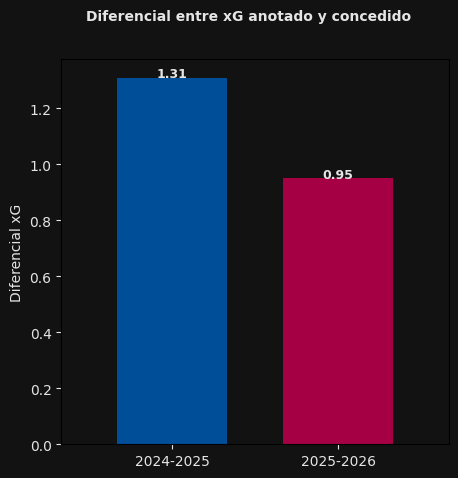

In [73]:
x = np.array([0, 0.3])#controla el centro de las barras
colores = [BARCA_BLAU, BARCA_GRANA]
plt.figure(figsize=(5,5))

# Fondo negro de la figura
plt.gcf().patch.set_facecolor("#121212")
ax = plt.gca()
ax.set_facecolor("#121212")

plt.bar(x, barca_stats['xG_diff/90'], color=colores, width=0.2)
ax.set_xlim(-0.2, 0.5)#controla el ancho del grafico

# Etiquetas sobre la barra
for i, v in enumerate(barca_stats['xG_diff/90']):
    plt.text(x[i], v + v*0.002, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold", color = BARCA_GRAY)
plt.ylabel('Diferencial xG', color= BARCA_GRAY)
plt.xticks(x, barca_stats['season'], color=BARCA_GRAY)
plt.tick_params(axis='both', colors = BARCA_GRAY)
plt.suptitle('Diferencial entre xG anotado y concedido', fontsize=10, fontweight="bold", color = BARCA_GRAY)


Barça 2024/2025

xG_diff_per90 = +1.31

Señal clara de un equipo muy superior: genera 1.31 xG más por partido de lo que concede.
Este nivel de dominancia es propio de equipos élite como Arsenal, Liverpool o Manchester City.

Barça 2025/2026

xG_diff_per90 = +0.95

Sigue siendo un diferencial positivo, pero mucho menor.
Este rendimiento corresponde a un equipo “bueno”, competitivo, pero no de élite.

Interpretación

El Barça pierde aproximadamente 27–28% de su dominancia real en términos de xG por 90’. No significa que el equipo produzca poco, sino que:

genera menos ventajas ofensivas sostenidas,

concede más volumen y calidad de ocasiones,

y deja de controlar los partidos con la misma autoridad.

Text(0.5, 0.98, 'Diferencial entre goles anotados y recibidos')

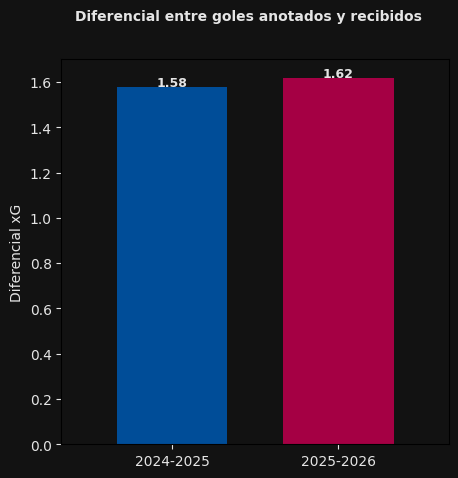

In [74]:
x = np.array([0, 0.3])#controla el centro de las barras
colores = [BARCA_BLAU, BARCA_GRANA]
plt.figure(figsize=(5,5))

# Fondo negro de la figura
plt.gcf().patch.set_facecolor("#121212")
ax = plt.gca()
ax.set_facecolor("#121212")

plt.bar(x, barca_stats['Gls_diff/90'], color=colores, width=0.2)
ax.set_xlim(-0.2, 0.5)#controla el ancho del grafico

# Etiquetas sobre la barra
for i, v in enumerate(barca_stats['Gls_diff/90']):
    plt.text(x[i], v + v*0.002, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold", color = BARCA_GRAY)
plt.ylabel('Diferencial xG', color= BARCA_GRAY)
plt.xticks(x, barca_stats['season'], color=BARCA_GRAY)
plt.tick_params(axis='both', colors = BARCA_GRAY)
plt.suptitle('Diferencial entre goles anotados y recibidos', fontsize=10, fontweight="bold", color = BARCA_GRAY)



El indicador Gls_diff_per90 mide cuántos goles más (o menos) marca un equipo respecto a los que recibe por partido. Es el saldo real del rendimiento, sin modelos avanzados:

Gls_diff_per90 = Gls_per90 – GA_per90

Barça 2024/25

Gls_diff_per90 = +1.58

Refleja un equipo claramente superior a sus rivales, con una estructura estable y una relación muy favorable entre goles anotados y goles encajados.

Barça 2025/26

Gls_diff_per90 = +1.62

El diferencial aumenta ligeramente respecto a la temporada anterior.
Esto ocurre porque:

el equipo anota más goles por 90’,

aunque concede más que en 2024/25,

la mejora ofensiva termina superando el deterioro defensivo.

Interpretación competitiva

Aunque el diferencial mejora, la calidad del rendimiento defensivo sí cae, lo que implica:

más partidos con intercambios abiertos,

menor capacidad de controlar ritmos y alturas,

dependencia mayor del acierto ofensivo para sostener resultados.

El Barça 25/26 no domina más: simplemente compensa una defensa más débil con una producción ofensiva superior.

En términos de juego, esto suele traducirse en:

menos control,

más volatilidad,

y un perfil competitivo más inestable pese al buen diferencial final.

In [34]:
stats_defense = pd.read_csv('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2024-2025/Archivos_utilizados/stats_defense_12_2024-2025.csv', header=1)

In [35]:
stats_defense.columns

Index(['Player', 'Nation', 'Pos', 'Age', '90s', 'Tkl', 'TklW', 'Def 3rd',
       'Mid 3rd', 'Att 3rd', 'Tkl.1', 'Att', 'Tkl%', 'Lost', 'Blocks', 'Sh',
       'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'Matches'],
      dtype='object')

In [36]:
stats_defense_IM = stats_defense.copy()
stats_defense_IM = stats_defense_IM[stats_defense_IM['Player']=='Iñigo Martínez']
stats_defense_IM = stats_defense_IM.iloc[:,:-1]
stats_defense_IM_rd = stats_defense_IM.copy()
stats_defense_IM_rd = stats_defense_IM_rd[['Player','90s', 'Tkl', 'TklW', 'Int', 'Blocks', 'Clr']]

stats_defense_IM_rd



,Player,90s,Tkl,TklW,Int,Blocks,Clr
6,Iñigo Martínez,27.7,25,14,18,18,108


In [37]:
for col in stats_defense_IM_rd.columns:
    if col != '90s' and col != 'Player':
        stats_defense_IM_rd[col] = round(stats_defense_IM_rd[col]/stats_defense_IM_rd['90s'],2)

stats_defense_IM_rd

,Player,90s,Tkl,TklW,Int,Blocks,Clr
6,Iñigo Martínez,27.7,0.9,0.51,0.65,0.65,3.9


In [38]:
stats_defense_IM_rd = stats_defense_IM_rd.drop(columns=['90s'])
stats_defense_IM_rd

,Player,Tkl,TklW,Int,Blocks,Clr
6,Iñigo Martínez,0.9,0.51,0.65,0.65,3.9


In [39]:
stats_defense = pd.read_csv('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2025-2026/Archivos_utilizados/stats_defense_12_2025-2026.csv', header=1)

In [40]:
stats_defense_players = stats_defense.copy()
stats_defense_players = stats_defense_players[(stats_defense_players['Player'] != 'Iñigo Martínez') & (stats_defense_players['Pos'] == 'DF')]
stats_defense_players = stats_defense_players[['Player','90s', 'Tkl', 'TklW', 'Int', 'Blocks', 'Clr']]
for col in stats_defense_players.columns:
    if col != '90s' and col != 'Player':
        stats_defense_players[col] = round(stats_defense_players[col]/stats_defense_players['90s'],2)
stats_defense_players = stats_defense_players.drop(columns=['90s'])
stats_defense_players.loc[len(stats_defense_players)] = {'Player':"Average",
                                                         'Tkl':round(stats_defense_players['Tkl'].aggregate('mean'),2),
                                                         'TklW':round(stats_defense_players['TklW'].aggregate('mean'),2),
                                                         'Int':round(stats_defense_players['Int'].aggregate('mean'),2),
                                                         'Blocks':round(stats_defense_players['Blocks'].aggregate('mean'),2),
                                                         'Clr':round(stats_defense_players['Clr'].aggregate('mean'),2)
                                                         }

stats_defense_players = stats_defense_players[stats_defense_players['Player']=='Average']
stats_defense_players

,Player,Tkl,TklW,Int,Blocks,Clr
7,Average,1.95,1.35,0.72,0.94,3.47


In [41]:
stats_standard = pd.read_csv('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2024-2025/Archivos_utilizados/stats_standard_12_2024-2025.csv', header=1)

In [42]:
stats_standard.columns

Index(['Player', 'Nation', 'Pos', 'Age', 'MP', 'Starts', 'Min', '90s', 'Gls',
       'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG',
       'xAG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR', 'Gls.1', 'Ast.1', 'G+A.1',
       'G-PK.1', 'G+A-PK', 'xG.1', 'xAG.1', 'xG+xAG', 'npxG.1', 'npxG+xAG.1',
       'Matches'],
      dtype='object')

In [43]:
stats_standard_IM = stats_standard[stats_standard['Player']=='Iñigo Martínez']
stats_standard_IM = stats_standard_IM.iloc[:,:-1]
stats_standard_IM_rd = stats_standard_IM.copy()
stats_standard_IM_rd = stats_standard_IM_rd[['Player','90s','PrgC', 'PrgP', 'PrgR']]
stats_standard_IM_rd

,Player,90s,PrgC,PrgP,PrgR
6,Iñigo Martínez,27.7,70,260,11


In [44]:
stats_standard_IM_rd.dtypes

Player    object
90s       object
PrgC      object
PrgP      object
PrgR      object
dtype: object

In [45]:
for col in stats_standard_IM_rd.columns:
    if col != '90s' and col != 'Player':
        stats_standard_IM_rd[col] = round(pd.to_numeric(stats_standard_IM_rd[col])/pd.to_numeric(stats_standard_IM_rd['90s']),2)

In [46]:
stats_standard_IM_rd

,Player,90s,PrgC,PrgP,PrgR
6,Iñigo Martínez,27.7,2.53,9.39,0.4


In [47]:
stats_standard_IM_rd = stats_standard_IM_rd.drop(columns=['90s'])
stats_standard_IM_rd

,Player,PrgC,PrgP,PrgR
6,Iñigo Martínez,2.53,9.39,0.4


In [48]:
stats_standard = pd.read_csv('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2025-2026/Archivos_utilizados/stats_standard_12_2025-2026.csv', header=1)

In [49]:
stats_standard_players = stats_standard.copy()
stats_standard_players = stats_standard_players[(stats_standard_players['Player'] != 'Iñigo Martínez') & (stats_standard_players['Pos'] == 'DF')]
stats_standard_players = stats_standard_players[['Player','90s', 'PrgC', 'PrgP', 'PrgR']]
for col in stats_standard_players.columns:
    if col != '90s' and col != 'Player':
        stats_standard_players[col] = round(pd.to_numeric(stats_standard_players[col])/pd.to_numeric(stats_standard_players['90s']),2)
stats_standard_players = stats_standard_players.drop(columns=['90s'])
stats_standard_players.loc[len(stats_standard_players)] = {'Player':"Average",
                                                         'PrgC':round(stats_standard_players['PrgC'].aggregate('mean'),2),
                                                         'PrgP':round(stats_standard_players['PrgP'].aggregate('mean'),2),
                                                         'PrgR':round(stats_standard_players['PrgR'].aggregate('mean'),2)
                                                         }

stats_standard_players = stats_standard_players[stats_standard_players['Player']=='Average']
stats_standard_players

,Player,PrgC,PrgP,PrgR
7,Average,1.22,4.32,4.92


In [50]:
stats_passing = pd.read_csv('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2024-2025/Archivos_utilizados/stats_passing_12_2024-2025.csv', header=1)

In [51]:
stats_passing.columns

Index(['Player', 'Nation', 'Pos', 'Age', '90s', 'Cmp', 'Att', 'Cmp%',
       'TotDist', 'PrgDist', 'Cmp.1', 'Att.1', 'Cmp%.1', 'Cmp.2', 'Att.2',
       'Cmp%.2', 'Cmp.3', 'Att.3', 'Cmp%.3', 'Ast', 'xAG', 'xA', 'A-xAG', 'KP',
       '1/3', 'PPA', 'CrsPA', 'PrgP', 'Matches'],
      dtype='object')

In [52]:
stats_passing_IM = stats_passing[stats_passing['Player']=='Iñigo Martínez']
stats_passing_IM = stats_passing_IM.iloc[:,:-1]
stats_passing_IM_rd = stats_passing_IM.copy()
stats_passing_IM_rd = stats_passing_IM_rd[['Player','90s','Att', 'Cmp%']]
stats_passing_IM_rd

,Player,90s,Att,Cmp%
6,Iñigo Martínez,27.7,2435,91.0


In [53]:
for col in stats_passing_IM_rd.columns:
    if col != '90s' and col == 'Att':
        stats_passing_IM_rd[col] = round(pd.to_numeric(stats_passing_IM_rd[col])/pd.to_numeric(stats_passing_IM_rd['90s']),2)

In [54]:
stats_passing_IM_rd = stats_passing_IM_rd.drop(columns=['90s'])
stats_passing_IM_rd

,Player,Att,Cmp%
6,Iñigo Martínez,87.91,91.0


In [55]:
stats_passing = pd.read_csv('/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/2025-2026/Archivos_utilizados/stats_passing_12_2025-2026.csv', header=1)

In [56]:
stats_passing_players = stats_passing.copy()
stats_passing_players = stats_passing_players[(stats_passing_players['Player'] != 'Iñigo Martínez') & (stats_passing_players['Pos'] == 'DF')]
stats_passing_players = stats_passing_players[['Player','90s', 'Att', 'Cmp', 'Cmp%']]
for col in stats_passing_players.columns:
    if col != '90s' and col != 'Player' and col != 'Cmp%':
        stats_passing_players[col] = round(pd.to_numeric(stats_passing_players[col])/pd.to_numeric(stats_passing_players['90s']),2)

# Cmp% NO se divide por 90
stats_passing_players['Cmp%'] = pd.to_numeric(stats_passing_players['Cmp%'])
stats_passing_players = stats_passing_players.drop(columns=['90s'])

# promedio ponderado correcto de Cmp%
cmp_pct_avg = round(
    (
        (stats_passing_players['Att'] * stats_passing_players['Cmp%'] / 100).sum()
        / stats_passing_players['Att'].sum()
    ) * 100,
    2
)

stats_passing_players.loc[len(stats_passing_players)] = {
    'Player': "Average",
    'Att': round(stats_passing_players['Att'].mean(), 2),
    'Cmp': round(stats_passing_players['Cmp'].mean(), 2),
    'Cmp%': cmp_pct_avg
}

stats_passing_players = stats_passing_players[stats_passing_players['Player']=='Average']
stats_passing_players 

,Player,Att,Cmp,Cmp%
7,Average,74.55,67.46,90.49


In [57]:
stats_IM = stats_defense_IM_rd.merge(stats_standard_IM_rd, on='Player',how='left')
stats_IM = stats_IM.merge(stats_passing_IM_rd, on='Player', how='left')
stats_IM

,Player,Tkl,TklW,Int,Blocks,Clr,PrgC,PrgP,PrgR,Att,Cmp%
0,Iñigo Martínez,0.9,0.51,0.65,0.65,3.9,2.53,9.39,0.4,87.91,91.0


In [58]:
stats_players = stats_defense_players.merge(stats_standard_players, on='Player', how='left')
stats_players = stats_players.merge(stats_passing_players, on='Player', how='left')
stats_players

,Player,Tkl,TklW,Int,Blocks,Clr,PrgC,PrgP,PrgR,Att,Cmp,Cmp%
0,Average,1.95,1.35,0.72,0.94,3.47,1.22,4.32,4.92,74.55,67.46,90.49


In [59]:
stats_team = pd.concat([stats_IM,stats_players], axis=0, ignore_index=True)
stats_team = stats_team.drop(columns=['Cmp'])
stats_team

,Player,Tkl,TklW,Int,Blocks,Clr,PrgC,PrgP,PrgR,Att,Cmp%
0,Iñigo Martínez,0.90,0.51,0.65,0.65,3.90,2.53,9.39,0.40,87.91,91.00
1,Average,1.95,1.35,0.72,0.94,3.47,1.22,4.32,4.92,74.55,90.49


In [210]:
def radar_jugadores(df, player1):
    metrics = ["Tkl", "TklW", "Int", "Blocks", "Clr", "PrgC", "PrgP", "PrgR", "Att", "Cmp%"]
    labels  = ["Tackles", "Tackles Ganados", "Intercepciones", "Bloqueos", "Despejes", "Conducciones progresivas", "Pases Progresivos", "Pases Progresivos rec", "Pases Intentados", "Pases Completados"]

    val_0 = df.loc[0,metrics].values
    val_1 = df.loc[1,metrics].values

    # 3) Rangos por métrica
    max_vals = np.maximum(val_0, val_1) * 1.1
    low = [0] * len(metrics)#[0] crea una lista con un elemento 0
    high = max_vals.tolist()
    radar = Radar(labels, low, high,
              num_rings=4,  # the number of concentric circles (excluding center circle)
              # if the ring_width is more than the center_circle_radius then
              # the center circle radius will be wider than the width of the concentric circles
              ring_width=1, center_circle_radius=1)
    # creating the figure using the grid function from mplsoccer:
    fig, axs = grid(figheight=7, grid_height=0.915, title_height=0.06, endnote_height=0.025,
                    title_space=0, endnote_space=0, grid_key='radar', axis=False)

    # plot the radar
    radar.setup_axis(ax=axs['radar'], facecolor='None')
    rings_inner = radar.draw_circles(ax=axs['radar'], facecolor='#28252c', edgecolor='#39353f', lw=1.5)
    radar_output = radar.draw_radar_compare(val_0, val_1, ax=axs['radar'],
                                            kwargs_radar={'facecolor': BARCA_GRANA, 'alpha': 0.6},
                                            kwargs_compare={'facecolor': BARCA_BLAU, 'alpha': 0.6})
    radar_poly, radar_poly2, vertices1, vertices2 = radar_output
    range_labels = radar.draw_range_labels(ax=axs['radar'], fontsize=10, color = BARCA_GRAY,
                                        fontproperties=robotto_thin.prop)
    param_labels = radar.draw_param_labels(ax=axs['radar'], fontsize=12, color = BARCA_GRAY,
                                        fontproperties=robotto_thin.prop)
    axs['radar'].scatter(vertices1[:, 0], vertices1[:, 1],
                        c= BARCA_GRANA, edgecolors='#6d6c6d', marker='o', s=150, zorder=2)
    axs['radar'].scatter(vertices2[:, 0], vertices2[:, 1],
                        c= BARCA_BLAU, edgecolors='#6d6c6d', marker='o', s=150, zorder=2)

    # adding the endnote and title text (these axes range from 0-1, i.e. 0, 0 is the bottom left)
    # Note we are slightly offsetting the text from the edges by 0.01 (1%, e.g. 0.99)

    title1_text = axs['title'].text(0.01, 0.65, 'Iñigo Martínez', fontsize=20, fontproperties=robotto_bold.prop, ha='left', va='center', color=BARCA_GRANA) 
    title2_text = axs['title'].text(0.01, 0.00, '2024-2025', fontsize=15, fontproperties=robotto_thin.prop, ha='left', va='center', color='#FFFFFF') 
    title3_text = axs['title'].text(0.99, 0.65, player1, fontsize=20, fontproperties=robotto_bold.prop, ha='right', va='center', color=BARCA_BLAU) 
    title4_text = axs['title'].text(0.99, 0.00, '2024-2025', fontsize=15, fontproperties=robotto_thin.prop, ha='right', va='center', color='#FFFFFF')

    fig.set_facecolor('#121212')
    

In [60]:
metrics = ["Tkl", "TklW", "Int", "Blocks", "Clr", "PrgC", "PrgP", "PrgR", "Att", "Cmp%"]
labels  = ["Tackles", "Tackles Ganados", "Intercepciones", "Bloqueos", "Despejes", "Conducciones progresivas", "Pases Progresivos", "Pases Progresivos rec", "Pases Intentados", "Pases Completados"]

val_0 = stats_team.loc[0,metrics].values
val_1 = stats_team.loc[1,metrics].values

# 3) Rangos por métrica
max_vals = np.maximum(val_0, val_1) * 1.1
low = [0] * len(metrics)#[0] crea una lista con un elemento 0
high = max_vals.tolist()

In [61]:
radar = Radar(labels, low, high,
              num_rings=4,  # the number of concentric circles (excluding center circle)
              # if the ring_width is more than the center_circle_radius then
              # the center circle radius will be wider than the width of the concentric circles
              ring_width=1, center_circle_radius=1)

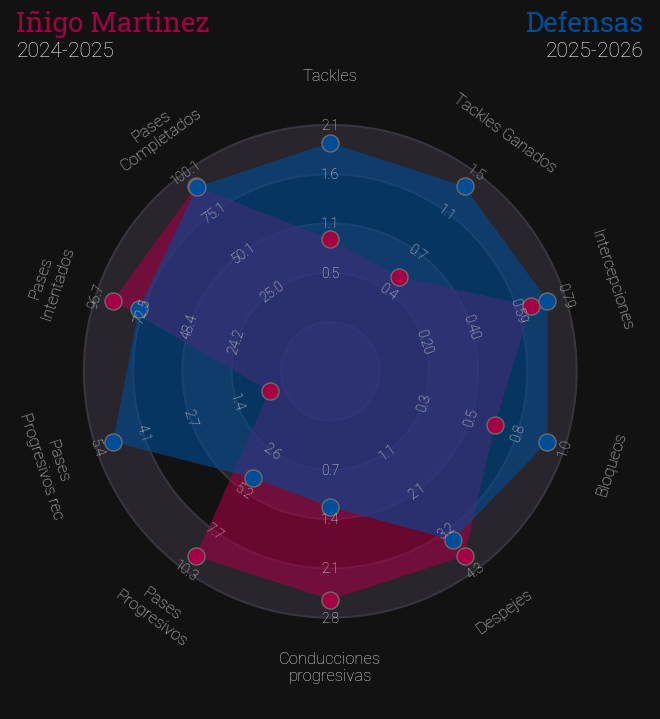

In [ ]:
# creating the figure using the grid function from mplsoccer:
fig, axs = grid(figheight=7, grid_height=0.915, title_height=0.06, endnote_height=0.025,
                title_space=0, endnote_space=0, grid_key='radar', axis=False)

# plot the radar
radar.setup_axis(ax=axs['radar'], facecolor='None')
rings_inner = radar.draw_circles(ax=axs['radar'], facecolor='#28252c', edgecolor='#39353f', lw=1.5)
radar_output = radar.draw_radar_compare(val_0, val_1, ax=axs['radar'],
                                        kwargs_radar={'facecolor': BARCA_GRANA, 'alpha': 0.6},
                                        kwargs_compare={'facecolor': BARCA_BLAU, 'alpha': 0.6})
radar_poly, radar_poly2, vertices1, vertices2 = radar_output
range_labels = radar.draw_range_labels(ax=axs['radar'], fontsize=10, color = BARCA_GRAY,
                                       fontproperties=robotto_thin.prop)
param_labels = radar.draw_param_labels(ax=axs['radar'], fontsize=12, color = BARCA_GRAY,
                                       fontproperties=robotto_thin.prop)
axs['radar'].scatter(vertices1[:, 0], vertices1[:, 1],
                     c= BARCA_GRANA, edgecolors='#6d6c6d', marker='o', s=150, zorder=2)
axs['radar'].scatter(vertices2[:, 0], vertices2[:, 1],
                     c= BARCA_BLAU, edgecolors='#6d6c6d', marker='o', s=150, zorder=2)

# adding the endnote and title text (these axes range from 0-1, i.e. 0, 0 is the bottom left)
# Note we are slightly offsetting the text from the edges by 0.01 (1%, e.g. 0.99)

title1_text = axs['title'].text(0.01, 0.65, 'Iñigo Martinez', fontsize=20, fontproperties=robotto_bold.prop, ha='left', va='center', color=BARCA_GRANA) 
title2_text = axs['title'].text(0.01, 0.00, '2024-2025', fontsize=15, fontproperties=robotto_thin.prop, ha='left', va='center', color='#FFFFFF') 
title3_text = axs['title'].text(0.99, 0.65, 'Defensas', fontsize=20, fontproperties=robotto_bold.prop, ha='right', va='center', color=BARCA_BLAU) 
title4_text = axs['title'].text(0.99, 0.00, '2025-2026', fontsize=15, fontproperties=robotto_thin.prop, ha='right', va='center', color='#FFFFFF')

fig.set_facecolor('#121212')

Perfil defensivo y estructural

Iñigo Martínez vs media defensas Barça 2025/26

Iñigo Martínez 2024/25
vs
Promedio defensas Barça 2025/26

La comparación no evalúa “quién defiende más”, sino qué tipo de defensa y control estructural aporta cada perfil.

Indicador: impacto defensivo–estructural

Las métricas analizadas (Tkl, Int, Blocks, Clr, PrgC, PrgP, Att, Cmp%) permiten entender cómo se defiende y cómo se sostiene el dominio del juego desde la base, no solo cuántas acciones defensivas se realizan.

Iñigo Martínez 2024/25

Iñigo presenta menor volumen de acciones defensivas directas:

menos tackles (0.90 vs 1.95),

menos tackles ganados (0.51 vs 1.35),

menos bloqueos (0.65 vs 0.94).

Esto no indica debilidad defensiva, sino un perfil claro:

👉 defensor preventivo, no reactivo.

Iñigo interviene menos porque:

llega antes a la jugada,

protege mejor los espacios intermedios,

reduce la necesidad de duelos y bloqueos de emergencia.

Además, destaca claramente en control y progresión:

PrgC: 2.53 (vs 1.22)

PrgP: 9.39 (vs 4.32)

Att: 87.9 pases por partido, con 91% de acierto

👉 Iñigo no solo defiende: organiza, fija altura y lanza al equipo hacia adelante.

Media defensas Barça 2025/26

El promedio defensivo 25/26 muestra el patrón opuesto:

más tackles,

más bloqueos,

más intercepciones reactivas.

Pero a costa de:

menos progresión por pase,

menos conducción limpia,

menor volumen de pase total.

👉 El equipo defiende más acciones, pero controla menos territorio.

La progresión se da más por recepción (PrgR 4.92) que por pase desde atrás, señal de una defensa:

menos dominante en la base,

más dependiente del mediocampo para avanzar,

más expuesta tras pérdida.

Interpretación competitiva

La ausencia de Iñigo Martínez no se traduce en un colapso defensivo inmediato, pero sí en un cambio profundo del perfil del equipo:

se pasa de una defensa preventiva y estructural

a una defensa más reactiva y de volumen.



Esto explica por qué en 2025/26:

sube el xGA,

cae el xG_diff,

y el control real de los partidos es menor.

Lectura final

El Barça 25/26 defiende más, pero domina menos. Sin Iñigo Martínez, el equipo pierde anticipación, control del espacio intermedio y calidad en las coberturas. El mediocampo protege menos y la línea defensiva queda más expuesta.

Iñigo Martínez no hacía al equipo mejor por acumular acciones defensivas, sino por evitar que fueran necesarias.

En términos de juego, su ausencia se traduce en:

menos control territorial,

más intercambios abiertos,

mayor volatilidad competitiva,

y una estructura más frágil pese a buenos resultados puntuales.

In [204]:
url = "https://fbref.com/stathead/player_comparison.cgi?request=1&sum=0&dom_lg=1&player_id1=3fc45c73&p1yrfrom=2024-2025&player_id2=34e12499&p2yrfrom=2024-2025"
player = 'Nico'
exfbref.scrape_and_save_comparison(url, player, headless=False)


Extraída tabla con ID: standard_stats
Extraída tabla con ID: shooting_stats
Extraída tabla con ID: passing_stats
Extraída tabla con ID: passing_types_stats
Extraída tabla con ID: gca_stats
Extraída tabla con ID: defense_stats
Extraída tabla con ID: possession_stats
Extraída tabla con ID: playing_time_stats
Extraída tabla con ID: misc_stats


{'standard_stats':    Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0  \
                Player               Span             Nation   
 0      Iñigo Martínez            2024-25             es ESP   
 1  Nico Schlotterbeck            2024-25             de GER   
 
   Unnamed: 3_level_0 Unnamed: 4_level_0 Playing Time                     \
                  Pos              Squad           MP Starts   Min   90s   
 0                 DF          Barcelona           28     28  2490  27.7   
 1                 DF           Dortmund           23     23  1982  22.0   
 
   Performance  ... Per 90 Minutes                                             \
           Gls  ...            Gls   Ast   G+A G-PK G+A-PK    xG   xAG xG+xAG   
 0           0  ...            0.0  0.14  0.14  0.0   0.14  0.02  0.10   0.11   
 1           0  ...            0.0  0.18  0.18  0.0   0.18  0.06  0.09   0.15   
 
                   
    npxG npxG+xAG  
 0  0.02     0.11  
 1  0.06     0.15  
 
 [2 rows x

In [191]:
path = '/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/comparison/Archivos_utilizados/passing_stats_Gonçalo.csv'
passing_Gonçalo_comp = lfbref.clean_comparison_stats(path)
passing_Gonçalo_comp

,Player,Att,Cmp%
0,Iñigo Martínez,87.91,91.0
1,Gonçalo Inácio,93.19,89.9


In [192]:
path = '/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/comparison/Archivos_utilizados/defense_stats_Gonçalo.csv'
defense_Gonçalo_comp = lfbref.clean_comparison_stats(path)
defense_Gonçalo_comp


,Player,Tkl,TklW,Int,Blocks,Clr
0,Iñigo Martínez,0.90,0.51,0.65,0.65,3.90
1,Gonçalo Inácio,1.78,1.26,0.81,1.04,2.96


In [193]:
path = '/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/comparison/Archivos_utilizados/standard_stats_Gonçalo.csv'
standard_Gonçalo_comp = lfbref.clean_comparison_stats(path)
standard_Gonçalo_comp

,Player,PrgC,PrgP,PrgR
0,Iñigo Martínez,2.53,9.39,0.40
1,Gonçalo Inácio,1.48,8.30,0.15


In [194]:
Gonçalo_comp = defense_Gonçalo_comp.merge(standard_Gonçalo_comp, on='Player', how='left')
Gonçalo_comp = Gonçalo_comp.merge(passing_Gonçalo_comp, on='Player', how='left')
Gonçalo_comp

,Player,Tkl,TklW,Int,Blocks,Clr,PrgC,PrgP,PrgR,Att,Cmp%
0,Iñigo Martínez,0.90,0.51,0.65,0.65,3.90,2.53,9.39,0.40,87.91,91.0
1,Gonçalo Inácio,1.78,1.26,0.81,1.04,2.96,1.48,8.30,0.15,93.19,89.9


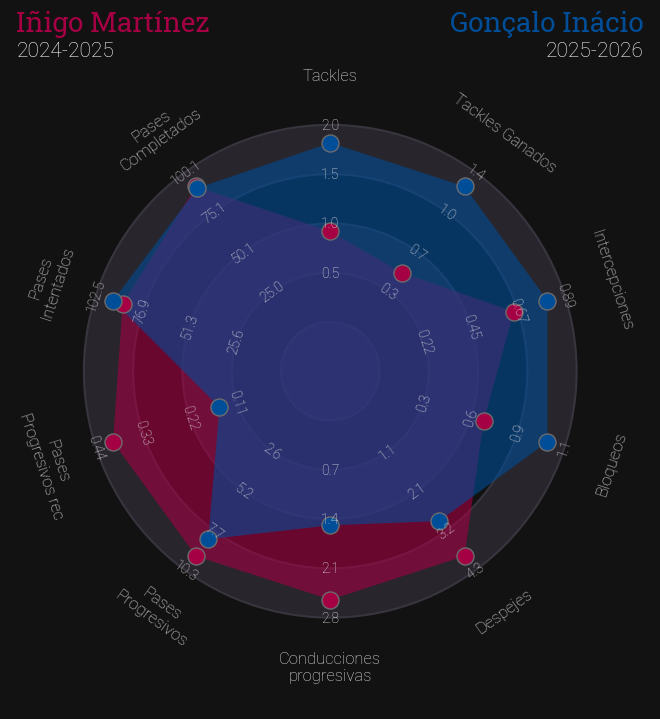

In [195]:
player = 'Gonçalo Inácio'
radar_jugadores(Gonçalo_comp, player)

In [205]:
path = '/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/comparison/Archivos_utilizados/passing_stats_Nico.csv'
passing_Nico_comp = lfbref.clean_comparison_stats(path)
passing_Nico_comp

,Player,Att,Cmp%
0,Iñigo Martínez,87.91,91.0
1,Nico Schlotterbeck,94.55,89.2


In [ ]:
path = '/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/comparison/Archivos_utilizados/defense_stats_Nico.csv'
defense_Nico_comp = lfbref.clean_comparison_stats(path)
defense_Nico_comp

,Player,Tkl,TklW,Int,Blocks,Clr
0,Iñigo Martínez,0.90,0.51,0.65,0.65,3.90
1,Nico Schlotterbeck,1.73,1.09,1.00,1.41,3.59


In [207]:
path = '/home/fjordan/Documentos/Estudios/Sport Data Campus/Master en Big Data Aplicado al Scouting en Futbol/Modulo 3/Tarea/Analisis_Barcelona/data/raw/comparison/Archivos_utilizados/standard_stats_Nico.csv'
standard_Nico_comp = lfbref.clean_comparison_stats(path)
standard_Nico_comp

,Player,PrgC,PrgP,PrgR
0,Iñigo Martínez,2.53,9.39,0.40
1,Nico Schlotterbeck,1.68,8.86,0.64


In [208]:
Nico_comp = defense_Nico_comp.merge(standard_Nico_comp, on='Player', how='left')
Nico_comp = Nico_comp.merge(passing_Nico_comp, on='Player', how='left')
Nico_comp

,Player,Tkl,TklW,Int,Blocks,Clr,PrgC,PrgP,PrgR,Att,Cmp%
0,Iñigo Martínez,0.90,0.51,0.65,0.65,3.90,2.53,9.39,0.40,87.91,91.0
1,Nico Schlotterbeck,1.73,1.09,1.00,1.41,3.59,1.68,8.86,0.64,94.55,89.2


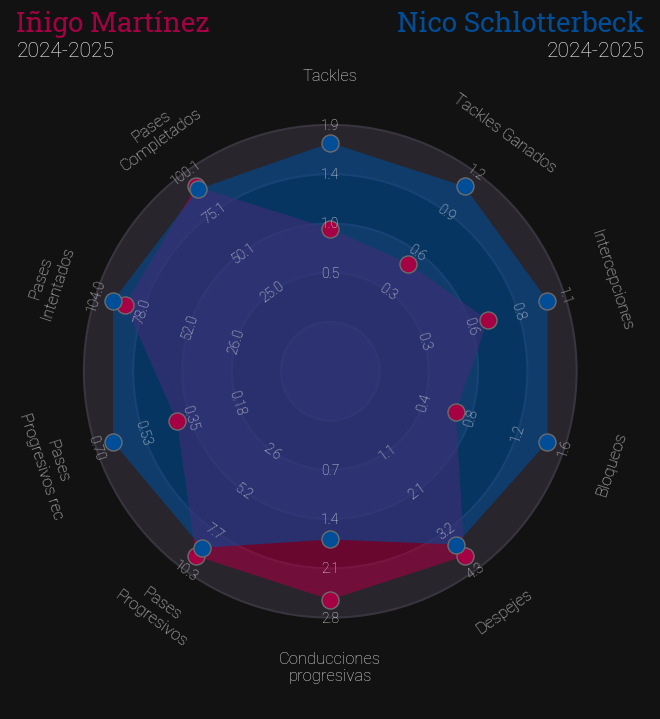

In [211]:
player = 'Nico Schlotterbeck'
radar_jugadores(Nico_comp, player)